In [88]:
import numpy as np
np.random.seed(103)
from vpsto.vpsto import VPSTO, VPSTOOptions
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from shapely.geometry import Polygon, MultiPolygon, Point, MultiPoint, LineString

In [89]:
# 定义优化选项
opt = VPSTOOptions(ndof=2)  # 2 个自由度
opt.vel_lim = np.array([0.1, 0.1])  # 速度限制
opt.acc_lim = np.array([0.5, 0.5])  # 加速度限制
opt.N_via = 4  # 途径点数量
# opt.N_eval = 100 # 评估点数量
opt.pop_size = 25  # 优化种群大小
opt.max_iter = 200  # 最大迭代次数
# opt.sigma_init = 1.5 # 初始标准差
 
# 创建优化器实例
traj_opt = VPSTO(opt)


In [90]:
## 定义损失函数 ##

# 1. 定义简单的时间最优损失函数

def loss(candidates):
    return candidates['T']  # 最小化轨迹持续时间
 
# 2. 定义带碰撞的损失函数

# 定义环境类，在其中包含多边形列表和计算轨迹与障碍物的距离的方法
class CollisionEnvironment():
    def __init__(self):
        self.poly_list = []
        self.poly_list.append(np.array([[0.1, 0.13], [0.23, 0.12], [0.19, 0.28], [0.1, 0.32], [0.16, 0.2]]))
        self.poly_list.append(np.array([[0.25, 0.34], [0.31, 0.35], [0.32, 0.41], [0.27, 0.44], [0.23, 0.4]]))
        self.poly_list.append(np.array([[0.35, 0.12], [0.38, 0.1], [0.41, 0.11], [0.42, 0.21], [0.35, 0.24]]))
        # self.poly_list.append(np.array([[0.4, 0.2], [0.6, 0.2], [0.6, 0.8], [0.4, 0.8]]))
        self.multi_poly = MultiPolygon([Polygon(self.poly_list[0]), Polygon(self.poly_list[1]), Polygon(self.poly_list[2])])
        
    def getTrajDist(self, pts):
        return self.multi_poly.intersection(LineString(pts)).length
# 创建碰撞环境实例
env = CollisionEnvironment()
# 位置限制
# 位置限制损失函数计算候选轨迹的每个位置点与限制范围的距离，如果距离小于0，则表示超出限制范围，否则表示在限制范围内。该损失函数的目标是最小化超出限制范围的成本，以使轨迹在限制范围内。
q_min = 0.0*np.ones(2)
q_max = 1.5*np.ones(2)
def loss_limits(candidates):
    q = candidates['pos']
    d_min = np.maximum(np.zeros_like(q), - q + q_min)
    d_max = np.maximum(np.zeros_like(q), q - q_max)
    return np.sum(d_min > 0.0, axis=(1,2)) + np.sum(d_max > 0.0, axis=(1,2))
# 碰撞限制
# 碰撞损失函数计算轨迹与障碍物的距离，如果距离大于0，则表示没有碰撞，否则表示发生了碰撞。该损失函数的目标是最小化碰撞成本，以避免轨迹与障碍物发生碰撞。
# 该损失函数的值越小，表示轨迹与障碍物的距离越大，碰撞的可能性越小。
# 该损失函数的实现是通过遍历候选轨迹的每个位置点，计算该点到障碍物的距离。如果距离大于0，则表示没有碰撞，成本为0；如果距离小于等于0，则表示发生了碰撞，成本为1。最终返回所有轨迹的碰撞成本。
# 该损失函数的实现使用了环境类中的getTrajDist方法，该方法计算轨迹与障碍物的距离。该方法使用了shapely库中的LineString和MultiPolygon类来表示轨迹和障碍物，并计算它们之间的交集长度。
def loss_collision(candidates): 
    costs = []
    for traj in candidates['pos']:
        costs.append(env.getTrajDist(traj))
    costs = np.array(costs)
    costs += costs > 0.0
    return costs
# 曲率损失函数
# 曲率损失函数计算轨迹的曲率，使用速度和加速度来衡量曲率的变化。曲率的计算公式为：
# K = (||dq||^2 * ||ddq||^2 - (dq·ddq)^2) / (||dq||^2)^3
# 其中 dq 是速度，ddq 是加速度，||.|| 表示向量的模长，dq·ddq 是速度和加速度的点积。
# 该损失函数的目标是最小化曲率，以使轨迹更加平滑。曲率损失函数的值越小，表示轨迹越平滑。
def loss_curvature(candidates):
    dq = candidates['vel']
    ddq = candidates['acc']
    dq_sq = np.sum(dq**2, axis=-1)
    ddq_sq = np.sum(ddq**2, axis=-1)
    dq_ddq = np.sum(dq*ddq, axis=-1) 
    return np.mean((dq_sq * ddq_sq - dq_ddq**2) / (dq_sq**3 + 1e-6), axis=-1)
# 综合损失函数
# 综合损失函数将时间、曲率、碰撞和位置限制的损失结合在一起，以便在优化过程中同时考虑这些因素。具体来说，它将时间损失作为主要目标，同时对曲率、碰撞和位置限制的损失进行加权处理
# 其中，曲率损失的权重为1e-3，碰撞损失和位置限制损失的权重均为1e3。这些权重可以根据实际需求进行调整，以平衡不同损失之间的影响。
# 综合损失函数的目标是最小化时间，同时确保轨迹平滑、避免碰撞并满足位置限制。通过这种方式，优化器可以在满足所有约束的前提下，找到最优的轨迹。
def loss_with_collision(candidates):
    cost_curvature = loss_curvature(candidates)
    cost_collision = loss_collision(candidates)
    cost_limits = loss_limits(candidates)
    # 综合损失函数，时间 + 曲率 + 碰撞 + 位置限制
    return candidates['T'] + 1e-3 * cost_curvature + 1e3 * cost_collision + 1e3 * cost_limits

In [91]:
# 定义起始和结束位置以及速度
q0 = np.array([0.0, 0.0])  # 起始位置
# qT = np.array([0.4, 0.5])  # 结束位置
qT = np.array([1.2, 1.3])  # 结束位置
dq0 = np.array([0.0, 0.0])  # 起始速度
dqT = np.array([0.0, 0.0])  # 结束速度
 
# 运行优化
solution = traj_opt.minimize(loss_with_collision, q0, qT=qT, dq0=dq0, dqT=dqT)

VP-STO finished after 200 iterations with a final loss of 17.370284304371424


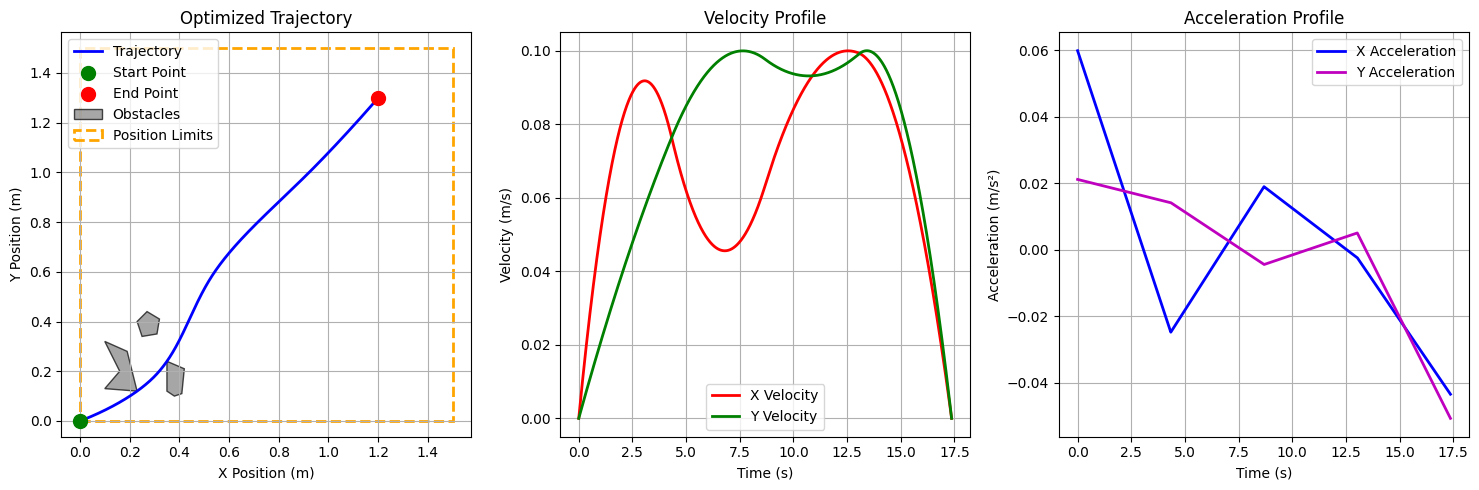

运动持续时间: 17.370 秒


In [92]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
 
# 获取优化后的轨迹
# t_traj = np.linspace(0, solution.T_best, 1000)
# 以 1 毫秒分辨率获取优化后的轨迹
t_traj = np.linspace(0, solution.T_best, int(solution.T_best * 1000))
pos, vel, acc = solution.get_posvelacc(t_traj)
 
# 绘制轨迹
plt.figure(figsize=(15, 5))

# 第一个子图：轨迹图
plt.subplot(1, 3, 1)
plt.plot(pos[:, 0], pos[:, 1], 'b-', linewidth=2, label='Trajectory')
plt.scatter([q0[0]], [q0[1]], c='green', s=100, zorder=5, label='Start Point')
plt.scatter([qT[0]], [qT[1]], c='red', s=100, zorder=5, label='End Point')

# 绘制障碍物
if 'env' in locals() or 'env' in globals():
    # 绘制多边形障碍物
    for i, poly_coords in enumerate(env.poly_list):
        # 创建多边形补丁
        polygon = patches.Polygon(poly_coords, closed=True, 
                                facecolor='gray', alpha=0.7, 
                                edgecolor='black', linewidth=1)
        plt.gca().add_patch(polygon)
        if i == 0:  # 只在第一个障碍物上添加标签
            polygon.set_label('Obstacles')

# 如果存在位置限制，绘制限制边界
if 'q_min' in locals() and 'q_max' in locals():
    # 绘制位置限制的边界框
    rect = patches.Rectangle((q_min[0], q_min[1]), 
                           q_max[0] - q_min[0], 
                           q_max[1] - q_min[1],
                           linewidth=2, edgecolor='orange', 
                           facecolor='none', linestyle='--',
                           label='Position Limits')
    plt.gca().add_patch(rect)

plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')
plt.title('Optimized Trajectory')
plt.grid(True)
plt.legend()
plt.axis('equal')  # 保持坐标轴比例一致

# 第二个子图：速度曲线
plt.subplot(1, 3, 2)
plt.plot(t_traj, vel[:, 0], 'r-', linewidth=2, label='X Velocity')
plt.plot(t_traj, vel[:, 1], 'g-', linewidth=2, label='Y Velocity')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Velocity Profile')
plt.grid(True)
plt.legend()

# 第三个子图：加速度曲线
plt.subplot(1, 3, 3)
plt.plot(t_traj, acc[:, 0], 'b-', linewidth=2, label='X Acceleration')
plt.plot(t_traj, acc[:, 1], 'm-', linewidth=2, label='Y Acceleration')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s²)')
plt.title('Acceleration Profile')
plt.grid(True)
plt.legend()
 
plt.tight_layout()
plt.show()
 
print(f'运动持续时间: {solution.T_best:.3f} 秒')